# Public Transport Delay Prediction using Machine Learning

## Model Explainability

### Objective

This notebook explains **why the final regression model makes its predictions**.

The final model from Notebook 4 is a **Tuned Random Forest Regressor**. Its test-set performance was:

- **MAE:** 7.7501 minutes
- **RMSE:** 9.2602 minutes
- **R²:** -0.0170

The purpose of this notebook is not to improve the model, but to make its behaviour understandable and inspect which features contribute most to its predictions.

### Explainability methods

1. Random Forest built-in feature importance
2. Permutation importance
3. SHAP global feature importance
4. SHAP local explanations for individual predictions

> **Important:** feature importance and SHAP values describe model behaviour and feature contributions. They do not establish causal relationships.

## Why Explain the Regression Model?

The regression model is the main continuous prediction model carried forward from Notebook 4.

The classification notebook identified a target-construction limitation: `delayed` exactly matches whether `actual_arrival_delay_min` exceeds five minutes, while realised delay variables are unavailable in a strict pre-trip setting.

For this reason, this notebook focuses its detailed explainability analysis on the **regression pipeline**, which predicts the continuous arrival delay from the engineered pre-trip features.

## Workflow

1. Load the saved regression pipeline
2. Load the exact regression test split from Notebook 2
3. Verify leakage and model structure
4. Confirm test predictions
5. Examine built-in Random Forest feature importance
6. Calculate permutation importance on the test data
7. Generate SHAP explanations
8. Aggregate one-hot encoded features to their original feature groups
9. Explain individual predictions
10. Save explainability results and figures


In [24]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error

import shap

print("Libraries imported successfully.")
print("SHAP version:", shap.__version__)


Libraries imported successfully.
SHAP version: 0.49.1


## Load the Saved Regression Pipeline

The complete pipeline contains both preprocessing and the trained Random Forest model.

Loading the pipeline rather than rebuilding preprocessing ensures that the explanations use exactly the same transformations as the final model.


In [25]:
model_path = '../artifacts/models/best_regression_pipeline.joblib'

if model_path is None:
    raise FileNotFoundError(
        "Could not find best_regression_pipeline.joblib. "
        "Run Notebook 4 and make sure the saved model exists."
    )

best_regression_pipeline = joblib.load(model_path)

print("Loaded model from:", model_path)
print("Pipeline steps:", list(best_regression_pipeline.named_steps.keys()))

Loaded model from: ../artifacts/models/best_regression_pipeline.joblib
Pipeline steps: ['preprocessor', 'model']


In [26]:
split_dir = '../artifacts/splits'

if split_dir is None:
    raise FileNotFoundError(
        "Could not find the saved regression split directory."
    )

X_test = pd.read_csv(split_dir + "/X_test_reg.csv")
y_test = pd.read_csv(split_dir + "/y_test_reg.csv").squeeze("columns")

print("Test features:", X_test.shape)
print("Test target:", y_test.shape)

Test features: (400, 33)
Test target: (400,)


## Test Dataset

The same regression test set used in Notebook 4 is used for explainability so that the explanations correspond directly to the final evaluated model.

The test set contains **400 observations and 33 original input features**.

No post-outcome delay variables are included in the explainability inputs.

In [27]:
categorical_features = [
    "transport_type",
    "route_id",
    "origin_station",
    "destination_station",
    "weather_condition",
    "event_type",
    "season",
    "day_of_week"
]

numerical_features = [
    "temperature_C",
    "humidity_percent",
    "wind_speed_kmh",
    "precipitation_mm",
    "traffic_congestion_index",
    "holiday",
    "peak_hour",
    "event_attendance_est",
    "log_event_attendance",
    "has_event",
    "year",
    "month",
    "day_of_month",
    "weekday_num",
    "is_weekend",
    "quarter",
    "departure_hour",
    "departure_minute",
    "arrival_hour",
    "arrival_minute",
    "departure_minutes",
    "arrival_minutes",
    "scheduled_trip_duration_min",
    "departure_hour_sin",
    "departure_hour_cos"
]

feature_columns = categorical_features + numerical_features

missing_columns = [
    column for column in feature_columns
    if column not in X_test.columns
]

if missing_columns:
    raise ValueError(
        "Missing expected regression features: "
        + ", ".join(missing_columns)
    )

X_test = X_test[feature_columns].copy()

print("Total original input features:", len(feature_columns))


Total original input features: 33


## Leakage Check

The explanations must only cover features that were permitted in the regression model.

The following post-outcome variables must not appear:

- `actual_departure_delay_min`
- `actual_arrival_delay_min`

`trip_id` is also excluded because it is an identifier rather than a predictive feature.


In [28]:
forbidden_columns = [
    "trip_id",
    "actual_departure_delay_min",
    "actual_arrival_delay_min"
]

present_forbidden = [
    column for column in forbidden_columns
    if column in X_test.columns
]

if present_forbidden:
    raise ValueError(
        "Forbidden columns found in explainability input: "
        + ", ".join(present_forbidden)
    )

print("Explainability leakage check passed.")

Explainability leakage check passed.


## Explainability Leakage Check

The explainability inputs contain only the same pre-trip features used by the final regression model.

The identifier `trip_id` and the post-outcome delay variables `actual_departure_delay_min` and `actual_arrival_delay_min` are excluded.

This ensures that the feature explanations correspond to the intended pre-trip prediction scenario.

## Verify the Saved Model

Before generating explanations, verify that the saved pipeline produces predictions successfully on the test data and reproduce the final test metrics from Notebook 4.

In [29]:
test_pred = best_regression_pipeline.predict(X_test)

verification_metrics = pd.DataFrame([{
    "MAE": mean_absolute_error(y_test, test_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
    "R2": 1 - (
        np.sum((y_test - test_pred) ** 2)
        / np.sum((y_test - y_test.mean()) ** 2)
    )
}])

verification_metrics.round(4)


,MAE,RMSE,R2
0,7.7501,9.2602,-0.017


## Saved Model Verification

The saved regression pipeline reproduces the final test-set metrics from Notebook 4:

- **MAE:** 7.7501 minutes
- **RMSE:** 9.2602 minutes
- **R²:** -0.0170

This confirms that the explainability analysis is being performed on the same final model evaluated previously.

## Extract Transformed Feature Names

The Random Forest does not receive the original 33 columns directly.

Categorical variables are one-hot encoded, so we extract the transformed feature names from the pipeline before inspecting the model's internal feature importance.

This allows the model-level explanations to be mapped back to readable feature names.

In [30]:
preprocessor = best_regression_pipeline.named_steps["preprocessor"]
model = best_regression_pipeline.named_steps["model"]

X_test_transformed = preprocessor.transform(X_test)

try:
    transformed_feature_names = preprocessor.get_feature_names_out()
except AttributeError:
    raise AttributeError(
        "The preprocessing pipeline does not expose transformed feature names."
    )

print("Transformed feature count:", len(transformed_feature_names))
print("Random Forest feature count:", model.n_features_in_)

if len(transformed_feature_names) != model.n_features_in_:
    raise ValueError("Feature-name count does not match model input dimension.")


Transformed feature count: 172
Random Forest feature count: 172


## Random Forest Built-In Feature Importance

Random Forest provides impurity-based feature importance through `feature_importances_`.

These values show how much each transformed feature contributes to the reduction in impurity across the fitted trees. They are useful for a first global view, but they can be affected by feature scale/cardinality and one-hot encoding.

For that reason, permutation importance is also calculated later.


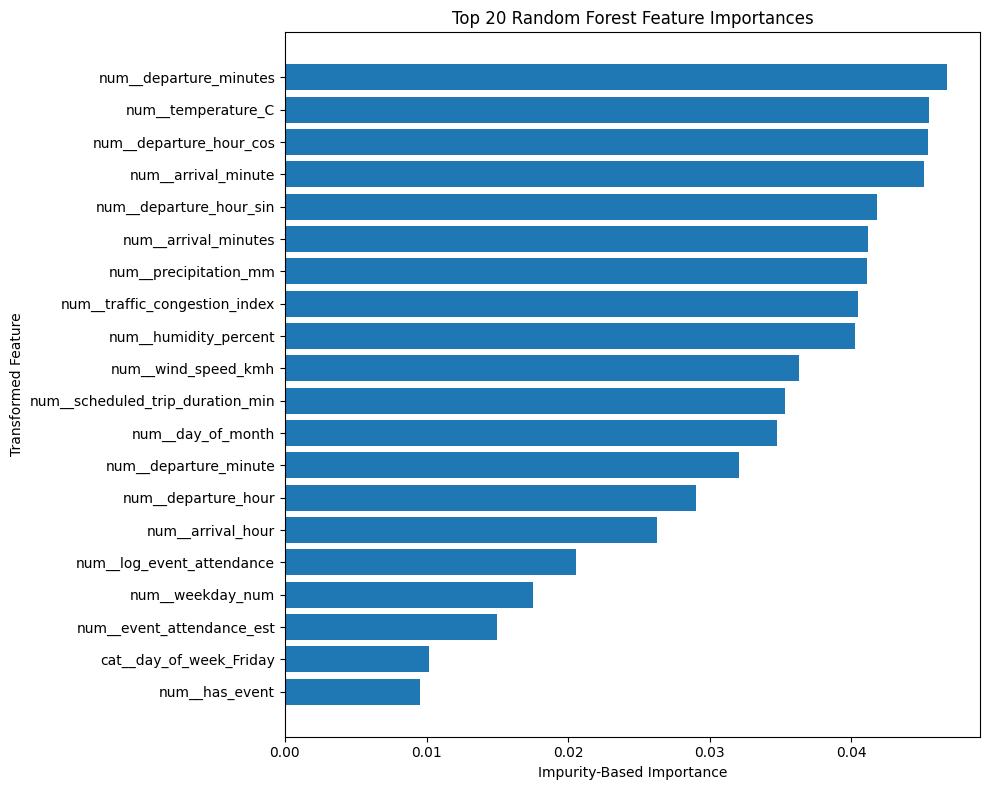

,feature,importance
20,num__departure_minutes,0.046735
0,num__temperature_C,0.045504
24,num__departure_hour_cos,0.045402
19,num__arrival_minute,0.045102
23,num__departure_hour_sin,0.041813
21,num__arrival_minutes,0.041165
3,num__precipitation_mm,0.041088
4,num__traffic_congestion_index,0.040493
1,num__humidity_percent,0.040268
2,num__wind_speed_kmh,0.036311


In [31]:
builtin_importance = pd.DataFrame({
    "feature": transformed_feature_names,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

top_builtin = builtin_importance.head(20).sort_values("importance")

plt.figure(figsize=(10, 8))
plt.barh(top_builtin["feature"], top_builtin["importance"])
plt.xlabel("Impurity-Based Importance")
plt.ylabel("Transformed Feature")
plt.title("Top 20 Random Forest Feature Importances")
plt.tight_layout()
plt.show()

display(builtin_importance.head(20).round(6))


## Built-In Random Forest Feature Importance — Interpretation

The Random Forest's built-in feature importance provides a global view of which transformed features were most frequently useful for reducing impurity across the decision trees.

In the results, several time-related and environmental variables appear among the higher-importance features, including `departure_minutes`, `temperature_C`, `departure_hour_cos`, `arrival_minute`, and `traffic_congestion_index`.

These values describe how the fitted model uses the features and should not be interpreted as causal relationships.

## Permutation Importance

Permutation importance measures how much model performance changes when one input feature is randomly shuffled while the other features remain unchanged.

Here it is calculated on the final test set using **negative RMSE** as the scoring metric. A larger positive importance means that shuffling the feature caused a larger deterioration in predictive performance.

This provides a model-agnostic global importance measure at the original feature level.


In [32]:
permutation = permutation_importance(
    best_regression_pipeline,
    X_test,
    y_test,
    scoring="neg_root_mean_squared_error",
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

permutation_df = (
    pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": permutation.importances_mean,
        "importance_std": permutation.importances_std
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

display(permutation_df.head(20).round(6))

,feature,importance_mean,importance_std
0,humidity_percent,0.007777,0.006697
1,departure_hour_sin,0.007183,0.004568
2,day_of_month,0.005107,0.006091
3,destination_station,0.004765,0.008667
4,origin_station,0.003851,0.009563
5,log_event_attendance,0.003822,0.006942
6,wind_speed_kmh,0.002912,0.004665
7,scheduled_trip_duration_min,0.002628,0.004843
8,day_of_week,0.001721,0.005553
9,peak_hour,0.001411,0.001848


## Permutation Importance — Interpretation

Permutation importance evaluates feature usefulness by measuring the change in model RMSE after randomly shuffling each original input feature.

In this test-set analysis, `humidity_percent`, `departure_hour_sin`, `day_of_month`, `destination_station`, and `origin_station` were among the features with the largest positive importance values.

A larger positive value indicates that the model's predictive performance deteriorated more when that feature was permuted.

Small values, including values close to zero or slightly negative, indicate that permuting the feature had little measurable effect on the model's RMSE for this test sample.

Permutation importance describes predictive dependence, not causation.

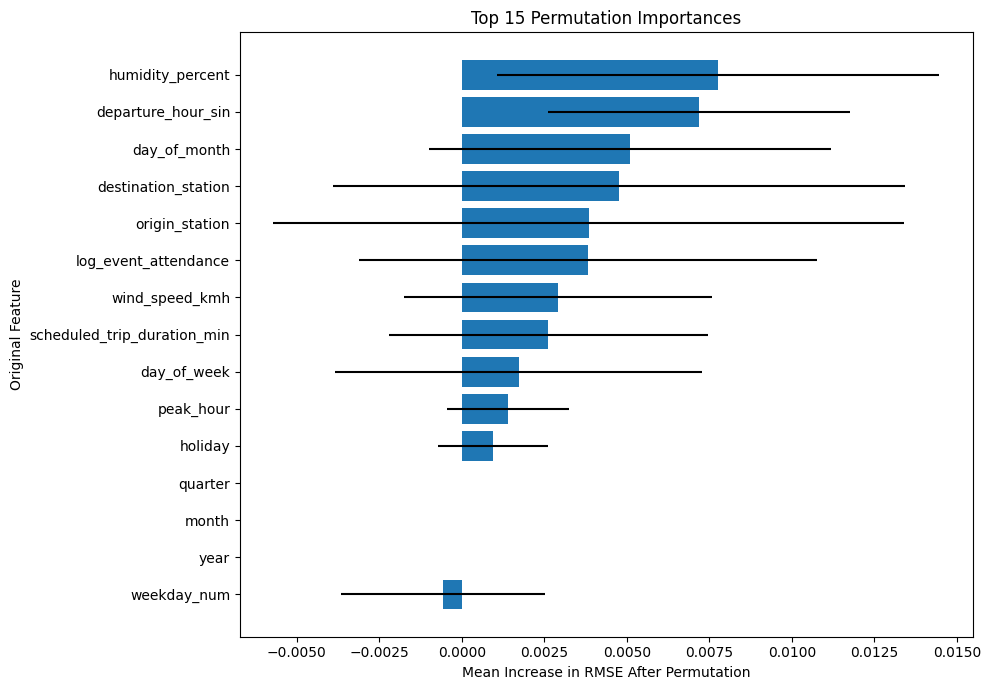

In [33]:
top_permutation = (
    permutation_df.head(15)
    .sort_values("importance_mean")
)

plt.figure(figsize=(10, 7))
plt.barh(
    top_permutation["feature"],
    top_permutation["importance_mean"],
    xerr=top_permutation["importance_std"]
)
plt.xlabel("Mean Increase in RMSE After Permutation")
plt.ylabel("Original Feature")
plt.title("Top 15 Permutation Importances")
plt.tight_layout()
plt.show()

## SHAP Explainability

SHAP (SHapley Additive exPlanations) attributes a model prediction to individual input features relative to a baseline prediction.

For the Random Forest, SHAP is calculated on the **transformed feature matrix** because the fitted model operates after imputation, scaling, and one-hot encoding.

A sample of the test set is used to keep the explanation computation efficient.


In [34]:
SHAP_SAMPLE_SIZE = min(100, len(X_test))

X_shap_raw = X_test.sample(
    n=SHAP_SAMPLE_SIZE,
    random_state=42
)

X_shap_transformed = preprocessor.transform(X_shap_raw)

shap_explainer = shap.TreeExplainer(model)
shap_values = shap_explainer.shap_values(X_shap_transformed)

shap_values = np.asarray(shap_values)

# Handle the regression output shape across SHAP versions.
if shap_values.ndim == 3:
    shap_values = shap_values[:, :, 0]

print("SHAP sample size:", SHAP_SAMPLE_SIZE)
print("SHAP matrix shape:", shap_values.shape)

SHAP sample size: 100
SHAP matrix shape: (100, 172)


## SHAP Calculation

SHAP explanations were calculated for a sample of **100 test observations** across the **172 transformed model features**.

The resulting SHAP matrix has dimensions **100 × 172**, where each value represents the contribution of one transformed feature to one model prediction relative to the model's baseline prediction.

A sample is used to keep the explainability computation efficient while providing a representative view of model behaviour.

## SHAP Global Summary

The SHAP summary plot combines **importance and direction**.

- Features with larger absolute SHAP values have a larger influence on individual predictions.
- Positive SHAP values push a prediction toward a higher delay.
- Negative SHAP values push a prediction toward a lower delay.

These explanations describe the behaviour of the fitted model; they should not be interpreted as causal effects.


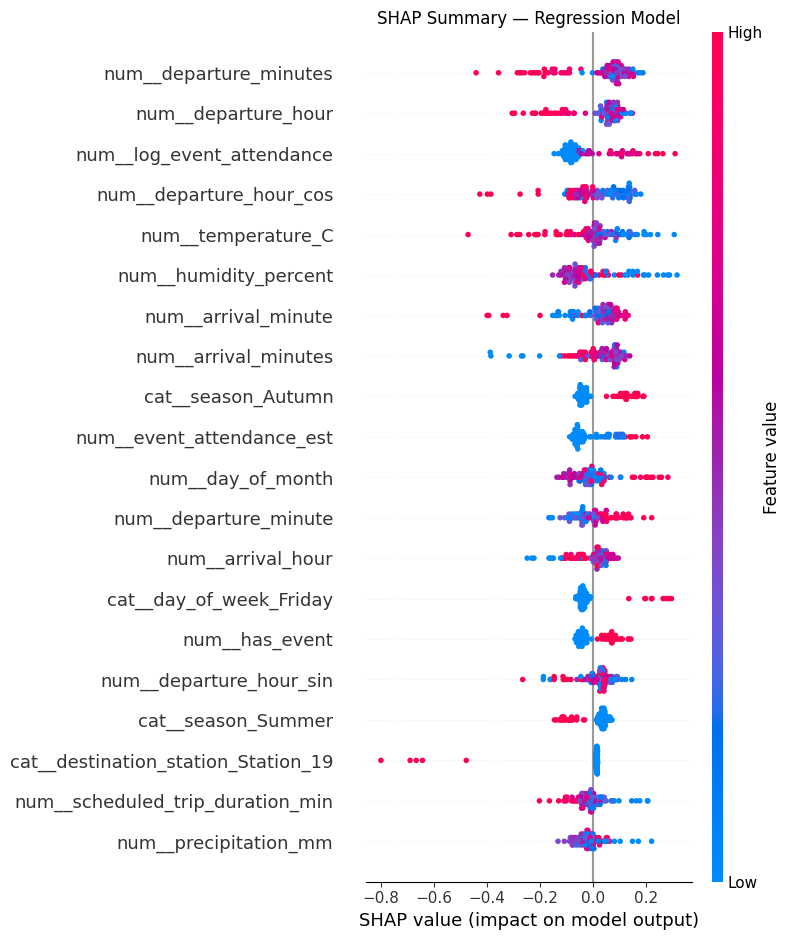

In [35]:
plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values,
    X_shap_transformed,
    feature_names=transformed_feature_names,
    show=False
)

plt.title("SHAP Summary — Regression Model")
plt.tight_layout()
plt.show()

## SHAP Global Summary — Interpretation

The SHAP summary plot provides both **feature importance and direction of influence** for the regression model.

Features appearing higher in the plot have larger average absolute SHAP values and therefore have a greater influence on the model's predictions.

The horizontal position of each point represents its SHAP value:

- Positive SHAP values push the prediction toward a higher arrival delay.
- Negative SHAP values push the prediction toward a lower arrival delay.
- Values closer to zero have a smaller contribution to the prediction.

The colour indicates the relative feature value for each observation, allowing the relationship between feature values and prediction direction to be examined.

These relationships describe the fitted model and should not be interpreted as causal effects.

## Aggregate One-Hot Encoded SHAP Values

One categorical feature can be represented by many one-hot columns, such as different `route_id` or `event_type` levels.

To make the explanation easier to interpret, SHAP magnitudes are also aggregated back to the original 33 features.

For one-hot groups, the mean absolute SHAP contribution across their encoded levels is combined into the original feature name.


In [36]:
def original_feature_name(transformed_name, original_features):
    cleaned = transformed_name.replace("num__", "").replace("cat__", "")

    for feature in sorted(original_features, key=len, reverse=True):
        if cleaned == feature or cleaned.startswith(feature + "_"):
            return feature

    return cleaned


original_features = feature_columns

shap_feature_map = {
    name: original_feature_name(name, original_features)
    for name in transformed_feature_names
}

# Absolute SHAP values
abs_shap = np.abs(shap_values)

# Aggregate one-hot encoded columns back to their original features
mapped_feature_names = [
    shap_feature_map[name]
    for name in transformed_feature_names
]

aggregated_values = {}

for feature in original_features:
    feature_indices = [
        i for i, mapped_name in enumerate(mapped_feature_names)
        if mapped_name == feature
    ]

    if feature_indices:
        # Sum contributions from all encoded levels for each observation,
        # then average across observations.
        aggregated_values[feature] = np.mean(
            np.sum(abs_shap[:, feature_indices], axis=1)
        )

aggregated_shap_importance = (
    pd.DataFrame(
        list(aggregated_values.items()),
        columns=["feature", "mean_abs_shap"]
    )
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

display(aggregated_shap_importance.head(20).round(6))

,feature,mean_abs_shap
0,destination_station,0.251434
1,origin_station,0.223264
2,season,0.160424
3,day_of_week,0.151365
4,route_id,0.149394
5,departure_minutes,0.116209
6,departure_hour,0.095260
7,log_event_attendance,0.094011
8,departure_hour_cos,0.085152
9,temperature_C,0.083594


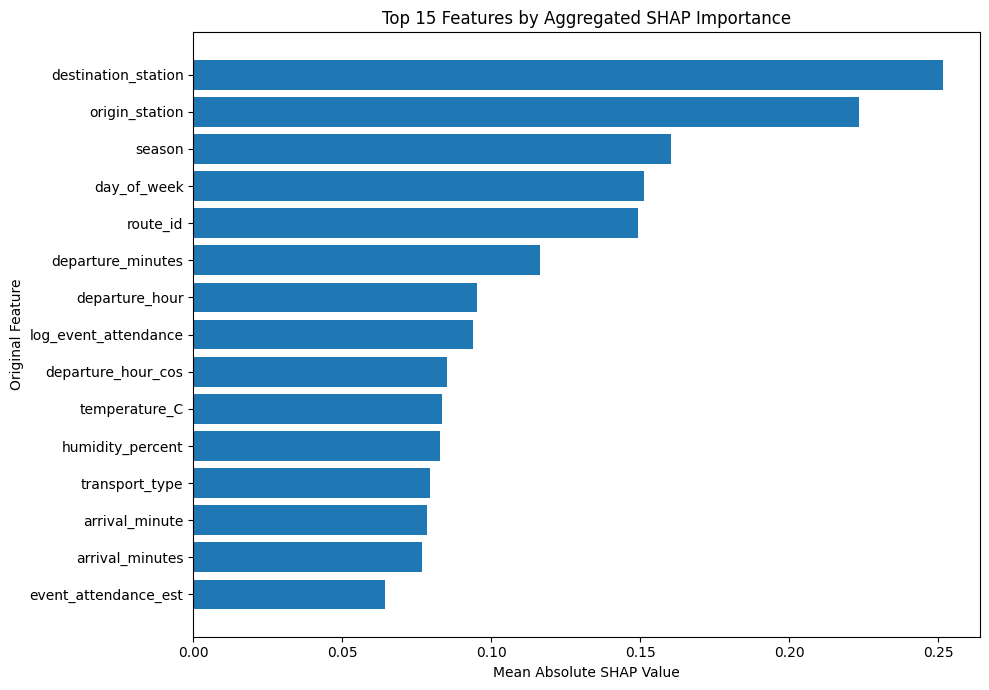

In [37]:
top_shap = (
    aggregated_shap_importance.head(15)
    .sort_values("mean_abs_shap")
)

plt.figure(figsize=(10, 7))
plt.barh(
    top_shap["feature"],
    top_shap["mean_abs_shap"]
)
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Original Feature")
plt.title("Top 15 Features by Aggregated SHAP Importance")
plt.tight_layout()
plt.show()


## Local Prediction Explanation

Global importance describes the model overall, but a practical ML system also needs to explain **individual predictions**.

The following example selects the test observation with the largest absolute prediction error and shows which transformed features pushed the prediction upward or downward relative to the model's baseline.


In [38]:
test_predictions_df = pd.DataFrame({
    "actual_delay": y_test.to_numpy(),
    "predicted_delay": test_pred,
    "absolute_error": np.abs(y_test.to_numpy() - test_pred)
}, index=X_test.index)

worst_index = test_predictions_df["absolute_error"].idxmax()

worst_row = X_test.loc[[worst_index]]
worst_actual = float(y_test.loc[worst_index])
worst_predicted = float(test_pred[list(X_test.index).index(worst_index)])

worst_transformed = preprocessor.transform(worst_row)
worst_shap_values = np.asarray(
    shap_explainer.shap_values(worst_transformed)
)

if worst_shap_values.ndim == 3:
    worst_shap_values = worst_shap_values[0, :, 0]
else:
    worst_shap_values = worst_shap_values[0]

print("Example test index:", worst_index)
print("Actual delay:", round(worst_actual, 4))
print("Predicted delay:", round(worst_predicted, 4))
print(
    "Absolute error:",
    round(abs(worst_actual - worst_predicted), 4)
)


Example test index: 3
Actual delay: -3.0
Predicted delay: 14.2069
Absolute error: 17.2069


## Local Prediction Example

A test observation with the largest absolute prediction error was selected to demonstrate a local explanation.

For this observation:

- **Actual arrival delay:** -3.0 minutes
- **Predicted arrival delay:** 14.2069 minutes
- **Absolute error:** 17.2069 minutes

The large error shows that the model predicted a substantial delay even though the observed outcome indicated a small early arrival.

SHAP is used next to examine which features contributed most strongly to this individual prediction.

In [39]:
local_explanation = pd.DataFrame({
    "feature": transformed_feature_names,
    "shap_value": worst_shap_values
})

local_explanation["absolute_shap"] = (
    local_explanation["shap_value"].abs()
)

local_explanation = (
    local_explanation
    .sort_values("absolute_shap", ascending=False)
    .reset_index(drop=True)
)

display(local_explanation.head(15).round(6))


,feature,shap_value,absolute_shap
0,num__temperature_C,0.306675,0.306675
1,num__scheduled_trip_duration_min,0.146397,0.146397
2,num__arrival_minute,0.122159,0.122159
3,num__departure_hour_cos,0.114658,0.114658
4,num__departure_hour,0.104414,0.104414
5,num__departure_minutes,0.088617,0.088617
6,num__log_event_attendance,-0.078454,0.078454
7,num__arrival_hour,0.076246,0.076246
8,num__event_attendance_est,-0.064189,0.064189
9,num__humidity_percent,-0.060122,0.060122


## Local SHAP Explanation — Interpretation

For the selected test observation, the largest positive SHAP contributions came from features such as `temperature_C`, `scheduled_trip_duration_min`, `arrival_minute`, `departure_hour_cos`, and `departure_hour`.

These features pushed the model's prediction toward a higher arrival delay relative to its baseline prediction.

Other features, including `log_event_attendance`, `event_attendance_est`, and `humidity_percent`, had negative SHAP values and therefore pushed the prediction downward.

The SHAP values explain the model's prediction for this particular observation; they do not explain the actual real-world cause of the observed delay.

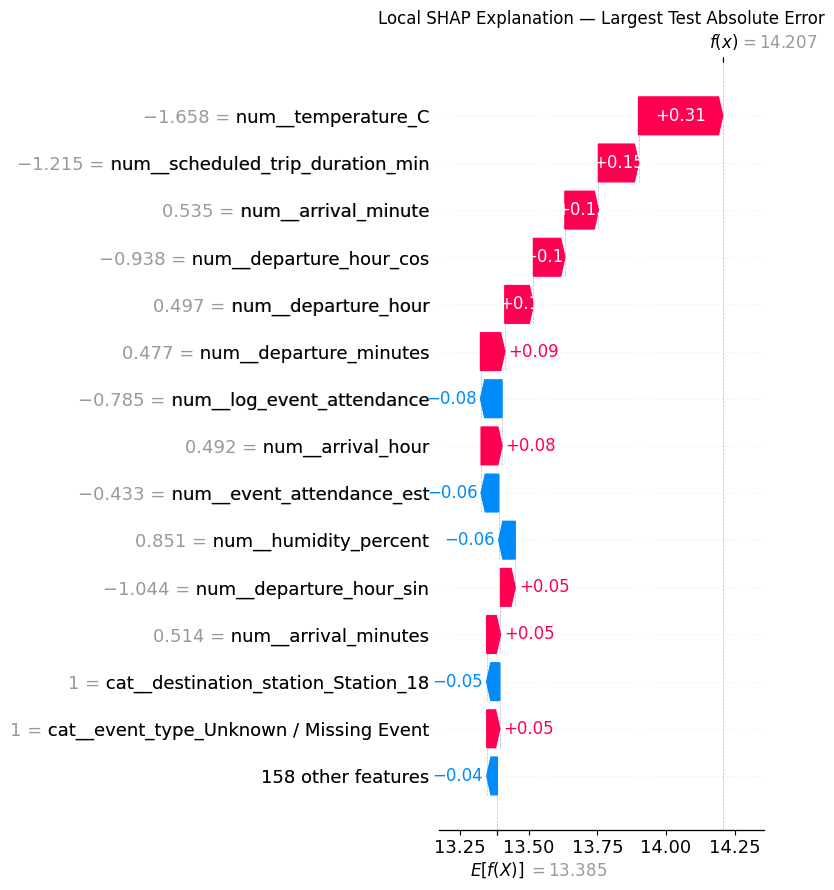

In [40]:
# SHAP waterfall plot for the selected individual prediction

base_value = float(np.asarray(shap_explainer.expected_value).reshape(-1)[0])

local_explanation_object = shap.Explanation(
    values=worst_shap_values,
    base_values=base_value,
    data=worst_transformed[0],
    feature_names=transformed_feature_names
)

shap.plots.waterfall(
    local_explanation_object,
    max_display=15,
    show=False
)

plt.title("Local SHAP Explanation — Largest Test Absolute Error")
plt.tight_layout()
plt.show()


## SHAP Waterfall Interpretation

The SHAP waterfall plot decomposes the selected prediction from the model's baseline value into individual feature contributions.

Features with positive contributions increase the predicted arrival delay, while features with negative contributions decrease it.

For this example, the combined feature contributions move the prediction toward approximately **14.21 minutes**, despite the actual observed delay being **-3 minutes**.

This example demonstrates how SHAP can make an individual model prediction transparent while also showing where the model's prediction differs substantially from the observed outcome.

## Local Explanation Interpretation

For the selected observation, positive SHAP values indicate transformed features that push the Random Forest prediction toward a higher arrival delay, while negative values push it toward a lower prediction.

The example is intentionally chosen from the test set with the largest absolute error. This highlights where the model's reasoning differs most from the observed outcome.

A local SHAP explanation describes **how the model arrived at its prediction**; it does not explain why the real-world delay occurred.


## Save Explainability Results

The explainability outputs are saved separately from the trained model so they can be reused in the project README, report, or later dashboard.

Saved outputs include:
- impurity-based Random Forest importance
- permutation importance
- aggregated SHAP importance
- local SHAP explanation


In [41]:
results_dir = Path("../results/explainability")
results_dir.mkdir(parents=True, exist_ok=True)

builtin_importance.to_csv(
    results_dir / "regression_builtin_feature_importance.csv",
    index=False
)

permutation_df.to_csv(
    results_dir / "regression_permutation_importance.csv",
    index=False
)

aggregated_shap_importance.to_csv(
    results_dir / "regression_shap_global_importance.csv",
    index=False
)

local_explanation.to_csv(
    results_dir / "regression_shap_local_explanation.csv",
    index=False
)

print("Explainability results saved to:", results_dir)


Explainability results saved to: ..\results\explainability


In [42]:
# Save the main explainability figures

feature_fig = results_dir / "regression_builtin_feature_importance.png"
perm_fig = results_dir / "regression_permutation_importance.png"
shap_fig = results_dir / "regression_shap_global_summary.png"
agg_shap_fig = results_dir / "regression_shap_aggregated_importance.png"
local_shap_fig = results_dir / "regression_shap_local_waterfall.png"

# Built-in importance
plt.figure(figsize=(10, 8))
plt.barh(top_builtin["feature"], top_builtin["importance"])
plt.xlabel("Impurity-Based Importance")
plt.ylabel("Transformed Feature")
plt.title("Top 20 Random Forest Feature Importances")
plt.tight_layout()
plt.savefig(feature_fig, dpi=200, bbox_inches="tight")
plt.close()

# Permutation importance
plt.figure(figsize=(10, 7))
plt.barh(
    top_permutation["feature"],
    top_permutation["importance_mean"],
    xerr=top_permutation["importance_std"]
)
plt.xlabel("Mean Increase in RMSE After Permutation")
plt.ylabel("Original Feature")
plt.title("Top 15 Permutation Importances")
plt.tight_layout()
plt.savefig(perm_fig, dpi=200, bbox_inches="tight")
plt.close()

# SHAP global summary
shap.summary_plot(
    shap_values,
    X_shap_transformed,
    feature_names=transformed_feature_names,
    show=False
)
plt.tight_layout()
plt.savefig(shap_fig, dpi=200, bbox_inches="tight")
plt.close()
plt.close("all")

# Aggregated SHAP
plt.figure(figsize=(10, 7))
plt.barh(top_shap["feature"], top_shap["mean_abs_shap"])
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Original Feature")
plt.title("Top 15 Features by Aggregated SHAP Importance")
plt.tight_layout()
plt.savefig(agg_shap_fig, dpi=200, bbox_inches="tight")
plt.close()

# Local waterfall
shap.plots.waterfall(
    local_explanation_object,
    max_display=15,
    show=False
)
plt.title("Local SHAP Explanation — Largest Test Absolute Error")
plt.tight_layout()
plt.savefig(local_shap_fig, dpi=200, bbox_inches="tight")
plt.close("all")

print("Explainability figures saved.")


Explainability figures saved.


## Model Explainability — Final Conclusion

The final Random Forest regression model from Notebook 4 was analysed using three complementary explainability approaches: built-in Random Forest feature importance, permutation importance, and SHAP.

The built-in feature importance provided a model-specific view of the transformed features used by the decision trees, while permutation importance evaluated how much model performance changed when individual original features were shuffled.

SHAP provided both global and local explanations. The global SHAP analysis identified the features with the largest average contribution to the model's predictions, while the local SHAP analysis demonstrated how individual features pushed a specific prediction toward a higher or lower arrival delay.

For the selected test observation, the model predicted an arrival delay of **14.2069 minutes** compared with the actual value of **-3.0 minutes**, resulting in an absolute error of **17.2069 minutes**. The local SHAP explanation showed which features contributed to this prediction.

Overall, the explainability analysis provides transparency into how the fitted Random Forest uses the available pre-trip features. However, feature importance and SHAP values describe model behaviour rather than causal relationships, and they do not overcome the underlying predictive limitations identified in Notebook 4.

The explainability results and figures were saved under:

`../results/explainability`

The next stage of the project is **MLflow experiment tracking**, where model parameters, evaluation metrics, experiments, and artefacts can be tracked systematically.